POWER PLANT ENEGRY PREDICTION USING ANN

In [1]:
# Importing Required Libraries/Packages
import pandas as pd


In [2]:
df = pd.read_csv("powerplant_data.csv")

In [3]:
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


In [4]:
df.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
# AT=> Temperature
# v => Vacuum
# AP => Pressure
# RH => Humidity

# PE => Produced Energy

In [6]:
# Looking for any possible null values
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [7]:
# Dropping PE from actual Dataset and making it output variable 
X = df.drop("PE", axis = 1)
Y = df["PE"]

In [8]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [9]:
Y.head()

0    480.48
1    445.75
2    438.76
3    453.09
4    464.43
Name: PE, dtype: float64

In [10]:
# Slitting data into training and testing
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(X,Y, test_size= 0.2, random_state=42)

In [11]:
# Standard Scaling X train and X test
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
X_train_scaled

array([[ 0.74805289,  0.72006931, -0.32660017, -0.49711722],
       [ 0.86181948,  1.26515721, -0.98521113,  0.8181501 ],
       [ 0.93409473,  1.52314975,  0.32523844,  0.80167494],
       ...,
       [-0.22097078, -0.834965  ,  0.36756563, -0.83554456],
       [ 0.94747903,  1.14245344, -0.41971997, -0.45455637],
       [-1.77355014, -1.19049131,  1.92520594,  0.91837402]],
      shape=(7654, 4))

In [13]:
# Converting Data to Tensors and creating Tesnor Dataset
import torch
import torch.nn as nn

X_train_tensor = torch.tensor(X_train_scaled, dtype = torch.float32)
Y_train_tensor = torch.tensor(Y_train.values, dtype = torch.float32).view(-1, 1) # Doing the view thing bcoz ytrain in not an array but a pandas series

X_test_tensor = torch.tensor(X_test_scaled, dtype = torch.float32)
Y_test_tensor = torch.tensor(Y_test.values, dtype = torch.float32).view(-1, 1)

In [14]:
from torch.utils.data import TensorDataset, DataLoader

# train_dataset = TensorDataset(in_features, out_features) CREATING A TESNSOR DATASET BY PROVIDING INPUT AND OUTPUT FEATURES
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

In [15]:
# Creating DataLoader Dataset
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=32)


DEEP LEARNING

In [16]:
X_train.shape

(7654, 4)

In [17]:
# Defining ANN model
class ANN(nn.Module):
    def __init__(self):
        super(ANN,self). __init__()
        self.model = nn.Sequential(
            # 1st Hidden Layer
            # nn.Linear(in_features, out_features)
            nn.Linear(X_train.shape[1], 6 ),
            nn.ReLU(),

            # 2nd Hidden Layer
            nn.Linear(6,6),
            nn.ReLU(),

            # Output Layer
            nn.Linear(6,1)
        )

    def forward(self,x):
        return self.model(x)

In [18]:
import torch.optim as optim
model = ANN()
# Difining Loss Fuction and Optimizer
Criterion = nn.MSELoss()
Optimizer = optim.Adam(model.parameters())

In [19]:
# Training The Model
Train_loss = []
val_loss = []
best_val_loss = float("inf")
epochs = 100
for epoch in range (epochs):
    model.train() # putting model in training mode
    running_loss = 0.0 # total training loss for 1 epoch

    for xb, yb in train_loader:
        # xb = features of 1 batch
        # yb = lables of 1 batch
        Optimizer.zero_grad()

        output = model(xb) # Predicted Outputs for 1 batch
        loss = Criterion(output, yb) # Computing the loss
        loss.backward() # backpropogation to compute gradients
        Optimizer.step() # parameters update

        running_loss += loss.item() # loss is a tensor => py float
    epoch_train_loss = running_loss/ len(train_loader)
    Train_loss.append(epoch_train_loss)
#___________________________________________________________________________________________________________________
    # Validation 
    model.eval() # putting model in evaluation/ prediction mode.
    running_val_loss = 0.0
    
    with torch.no_grad():     # No Gradient to Compute during back prop..
        for xb, yb in test_loader:
            output = model(xb)
            loss = Criterion(output, yb)
            running_val_loss += loss.item() 
 
    epoch_val_loss = running_val_loss/ len(test_loader)
    val_loss.append(epoch_val_loss)
    print(f" epoch {epoch+1}/{epochs} ==> train loss ={epoch_train_loss} & val loss = {epoch_val_loss}")
     # Saving the best model. 
    if epoch_val_loss < best_val_loss:
        best_val_loss = epoch_val_loss
        torch.save(model.state_dict(),"best_model.pt")






 epoch 1/100 ==> train loss =205029.54654947916 & val loss = 201626.43515625
 epoch 2/100 ==> train loss =191472.45071614583 & val loss = 176259.60078125
 epoch 3/100 ==> train loss =153444.741015625 & val loss = 127646.501953125
 epoch 4/100 ==> train loss =102656.10691731771 & val loss = 80245.40377604167
 epoch 5/100 ==> train loss =65417.24939778646 & val loss = 51141.61569010417
 epoch 6/100 ==> train loss =39648.56633300781 & val loss = 28188.721842447918
 epoch 7/100 ==> train loss =20863.680830891928 & val loss = 14324.345621744791
 epoch 8/100 ==> train loss =11170.026143391928 & val loss = 8554.292521158854
 epoch 9/100 ==> train loss =7164.287465413411 & val loss = 5911.631530761719
 epoch 10/100 ==> train loss =5042.310142008463 & val loss = 4329.790738932292
 epoch 11/100 ==> train loss =3779.226877339681 & val loss = 3291.128446451823
 epoch 12/100 ==> train loss =2917.1605814615887 & val loss = 2569.5557861328125
 epoch 13/100 ==> train loss =2326.859329477946 & val loss

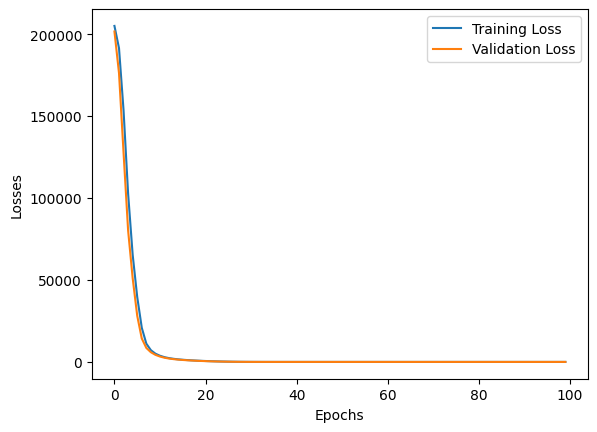

In [20]:
# PLOTTING THE LOSS

import matplotlib.pyplot as plt

loss_df = pd.DataFrame({ 
    "Training Loss": Train_loss,
    "Validation Loss": val_loss
})

plt.plot(loss_df["Training Loss"], label = "Training Loss")
plt.plot(loss_df["Validation Loss"], label = "Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Losses")

plt.legend()

In [21]:
# Loading the best model.

model.load_state_dict(torch.load("best_model.pt"))




<All keys matched successfully>

In [22]:
# Model Evaluation
model.eval()
with torch.no_grad():
    train_pred = model(X_train_tensor)
    test_pred = model(X_test_tensor)

    train_mse_loss = Criterion(train_pred, Y_train_tensor)
    test_mse_loss = Criterion(test_pred, Y_test_tensor)
print("Training MSE:", train_mse_loss.item())
print("Testiong MSE:", test_mse_loss.item())

Training MSE: 20.615997314453125
Testiong MSE: 18.791948318481445


In [23]:
# Calculating R Squared 
from sklearn.metrics import r2_score

print("r^2 score:", r2_score(Y_test, test_pred))

r^2 score: 0.9343269926529341


In [25]:
# Comparing Actual and Predict values

pred_df = pd.DataFrame(test_pred.numpy(), columns = ["Predicted values"])
actual_df = pd.DataFrame(Y_test.values, columns = ["Actual Values"])

pd.concat([pred_df,actual_df], axis = "columns")

,Predicted values,Actual Values
0,435.015533,433.27
1,436.798431,438.16
2,461.085510,458.42
3,476.187439,480.82
4,435.001740,441.41
...,...,...
1909,451.235931,456.70
1910,431.418060,438.04
1911,467.505096,467.80
1912,430.865967,437.14
